In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import matplotlib.pyplot as plt
import logging
from urllib.parse import urljoin, urlparse

# Konfigurasi logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [2]:
def fetch_article_urls(domain, base_url, max_articles=1000):
    """
    Mengambil URL artikel dari homepage suatu situs berita.
    - domain: substring domain untuk filtering (misal: "kompas.com")
    - base_url: URL homepage situs
    - max_articles: batas maksimum artikel yang diambil per situs
    """
    try:
        response = requests.get(base_url, timeout=1000)
        response.raise_for_status()
    except Exception as e:
        logging.error(f"Gagal mengakses {base_url}: {e}")
        return []

    soup = BeautifulSoup(response.text, 'html.parser')
    links = set()
    for a in soup.find_all('a', href=True):
        href = a['href']
        full_url = urljoin(base_url, href)
        parsed = urlparse(full_url)
        # Filter dengan memastikan domain target terdapat pada netloc
        if domain in parsed.netloc.lower():
            links.add(full_url)
    links = list(links)
    logging.info(f"{len(links)} URL ditemukan untuk {domain}")
    # Batasi jumlah artikel per sumber
    return links[:max_articles]

In [3]:
def scrape_news(url):
    """
    Scrape artikel dari URL berita, mengambil judul, tanggal, penulis, dan konten.
    Jika terjadi error, fungsi mengembalikan None.
    """
    try:
        response = requests.get(url, timeout=1000)
        response.raise_for_status()
    except Exception as e:
        logging.error(f"Gagal mengakses {url}: {e}")
        return None

    soup = BeautifulSoup(response.text, 'html.parser')
    # Upaya pengambilan data secara generik (mungkin perlu disesuaikan per situs)
    title = soup.find('h1').get_text(strip=True) if soup.find('h1') else ''

    # Ambil tanggal dari tag <time> atau ambil teks jika atribut 'datetime' tidak ada
    date = ''
    time_tag = soup.find('time')
    if time_tag:
        date = time_tag.get('datetime', time_tag.get_text(strip=True))

    # Ambil nama penulis, jika ada
    author = ''
    author_tag = soup.find(class_='author')
    if author_tag:
        author = author_tag.get_text(strip=True)

    content = ' '.join(p.get_text(strip=True) for p in soup.find_all('p'))
    data = {
        'title': title,
        'date': date,
        'author': author,
        'content': content,
        'source': url,
        'label': 'non-hoax'
    }
    return data

In [4]:
def scrape_ground_truth(url, label='hoax'):
    """
    Scrape artikel ground truth dari URL target (misalnya Komdigi dan Turnback Hoax)
    dan beri label sesuai.
    """
    try:
        response = requests.get(url, timeout=1000)
        response.raise_for_status()
    except Exception as e:
        logging.error(f"Gagal mengakses {url}: {e}")
        return []

    soup = BeautifulSoup(response.text, 'html.parser')
    articles = soup.find_all('article')
    data_list = []
    for article in articles:
        title = article.find('h2').get_text(strip=True) if article.find('h2') else ''
        date = article.find('time')['datetime'] if article.find('time') and article.find('time').has_attr('datetime') else ''
        author = article.find(class_='author').get_text(strip=True) if article.find(class_='author') else ''
        content = ' '.join(p.get_text(strip=True) for p in article.find_all('p'))
        data_list.append({
            'title': title,
            'date': date,
            'author': author,
            'content': content,
            'source': url,
            'label': label
        })
    return data_list

In [5]:
def preprocess_text(text):
    """
    Preprocessing sederhana: mengubah ke huruf kecil, menghapus spasi berlebih dan karakter khusus.
    """
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

In [6]:
def preprocess_data(df):
    """
    Terapkan preprocessing pada kolom 'content' dan simpan di kolom 'clean_content'.
    """
    df['clean_content'] = df['content'].apply(preprocess_text)
    return df

In [7]:
def exploratory_data_analysis(df):
    """
    Analisis eksploratori sederhana: tampilkan distribusi artikel berdasarkan label.
    """
    label_counts = df['label'].value_counts()
    logging.info("Jumlah artikel per label:")
    logging.info("\n" + str(label_counts))

    plt.figure(figsize=(6, 4))
    label_counts.plot(kind='bar', color=['skyblue', 'salmon'])
    plt.xlabel('Label')
    plt.ylabel('Jumlah Artikel')
    plt.title('Distribusi Artikel Berdasarkan Label')
    plt.tight_layout()
    plt.show()

ERROR:root:Gagal mengakses https://pesonaindonesia.kompas.com?source=kompascom&medium=footer: 500 Server Error: Internal Server Error for url: https://pesonaindonesia.kompas.com/?source=kompascom&medium=footer
ERROR:root:Gagal mengakses https://www.detik.com/hoegeng-awards: 418 Client Error:  for url: https://www.detik.com/hoegeng-awards
ERROR:root:Gagal mengakses https://www.detik.com/hoegeng-awards/submission: 418 Client Error:  for url: https://www.detik.com/hoegeng-awards/submission
ERROR:root:Gagal mengakses https://www.tempo.co/digital/teknologi-ai-di-mata-anne-bouverot-1207505: 429 Client Error: Too Many Requests for url: https://www.tempo.co/digital/teknologi-ai-di-mata-anne-bouverot-1207505
ERROR:root:Gagal mengakses https://www.tempo.co/gaya-hidup/olahraga-saat-puasa-ramadan-apa-yang-perlu-diperhatikan-agar-aman-bagi-kesehatan--1214024: 429 Client Error: Too Many Requests for url: https://www.tempo.co/gaya-hidup/olahraga-saat-puasa-ramadan-apa-yang-perlu-diperhatikan-agar-ama

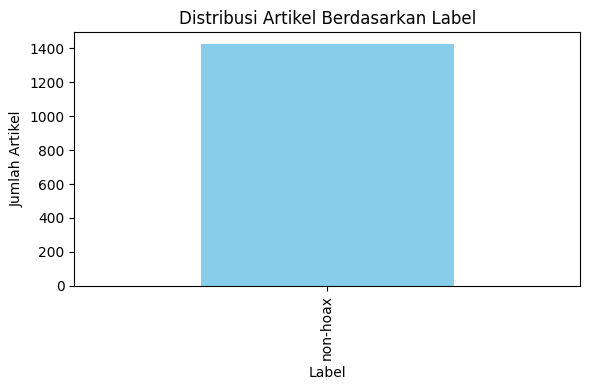

In [8]:
def main():
    # Daftar situs berita target untuk data umum
    news_sources = {
        "liputan6.com": "https://www.liputan6.com/",
        "kompas.com": "https://www.kompas.com/",
        "cnnindonesia.com": "https://www.cnnindonesia.com/",
        "detik.com": "https://www.detik.com/",
        "tempo.co": "https://www.tempo.co/",
        "antaranews.com": "https://www.antaranews.com/",
        "sindonews.com": "https://www.sindonews.com/",
        "tribunnews.com": "https://www.tribunnews.com/",
        "cnbcindonesia.com": "https://www.cnbcindonesia.com/"
    }
    max_articles_per_source = 1000  # Batas jumlah artikel per sumber
    scraped_data = []

    # Lakukan crawling untuk tiap situs berita
    for domain, base_url in news_sources.items():
        article_urls = fetch_article_urls(domain, base_url, max_articles=max_articles_per_source)
        logging.info(f"Scraping {len(article_urls)} artikel dari {domain}")
        for url in article_urls:
            data = scrape_news(url)
            if data:
                scraped_data.append(data)

    if not scraped_data:
        logging.warning("Tidak ada data berita umum yang berhasil di-scrape.")

    # Data ground truth (hoax) tetap dari Komdigi dan Turnback Hoax
    komdigi_url = 'https://www.komdigi.go.id/berita/berita-hoaks'
    turnback_url = 'https://turnbackhoax.id/'
    ground_truth_data = []
    ground_truth_data.extend(scrape_ground_truth(komdigi_url, label='hoax'))
    ground_truth_data.extend(scrape_ground_truth(turnback_url, label='hoax'))

    # Gabungkan seluruh data yang telah dikumpulkan
    all_data = scraped_data + ground_truth_data
    if not all_data:
        logging.error("Tidak ada data yang berhasil dikumpulkan. Proses dihentikan.")
        return

    df = pd.DataFrame(all_data)
    df = preprocess_data(df)
    exploratory_data_analysis(df)

    # Simpan data ke file CSV
    df.to_csv('news_data.csv', index=False)
    logging.info("Data telah disimpan ke file news_data.csv")

if __name__ == "__main__":
    main()